In [1]:
!pip install -U tensorflow matplotlib scikit-learn seaborn
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 142.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 59.5 MB/s eta 0:00:00
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.19.0
    Uninstalling tensorboard-2.19.0:
      Successfully uninstalled tensorboard-2.19.0
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.10.0
    Uninstalling matplotlib-3.10.0:
      Successfully uninstalled matplotlib-3.10.0
  Attempting uninstall: tensorflow
    Found existing installation: tensorflow 2.19.0
    Uninstalling tensorflow-2.19.0:
      Successfully uninstalled tensorflow-2.1

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/devanagari.zip"  # 🔹 change if name/path differs
extract_path = "/content/devanagari_dataset"

if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Dataset extracted successfully.")
else:
    print("Dataset already extracted.")


Dataset extracted successfully.


In [3]:
!pip install -U tensorflow matplotlib scikit-learn seaborn

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


In [4]:
IMG_SIZE = 64
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/devanagari_dataset/Train",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/devanagari_dataset/Test",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Total Classes:", num_classes)


Found 78200 files belonging to 46 classes.
Found 13800 files belonging to 46 classes.
Total Classes: 46


In [5]:
AUTOTUNE = tf.data.AUTOTUNE
normalization_layer = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

train_ds = train_ds.shuffle(1000).prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)


In [6]:
class Patches(layers.Layer):
    def __init__(self, patch_size):
        super().__init__()
        self.patch_size = patch_size

    def call(self, images):
        batch_size = tf.shape(images)[0]
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding="VALID"
        )
        patch_dims = patches.shape[-1]
        patches = tf.reshape(patches, [batch_size, -1, patch_dims])
        return patches


In [7]:
class PatchEncoder(layers.Layer):
    def __init__(self, num_patches, projection_dim):
        super().__init__()
        self.num_patches = num_patches
        self.projection = layers.Dense(units=projection_dim)
        self.position_embedding = layers.Embedding(input_dim=num_patches, output_dim=projection_dim)

    def call(self, patches):
        positions = tf.range(start=0, limit=self.num_patches, delta=1)
        encoded = self.projection(patches) + self.position_embedding(positions)
        return encoded


In [8]:
def create_vit_classifier(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    patch_size=8,
    projection_dim=64,
    transformer_layers=6,
    num_heads=4,
    mlp_dim=128,
    dropout_rate=0.1
):
    num_patches = (input_shape[0] // patch_size) ** 2

    inputs = layers.Input(shape=input_shape)
    patches = Patches(patch_size)(inputs)
    encoded_patches = PatchEncoder(num_patches, projection_dim)(patches)

    for _ in range(transformer_layers):
        # Normalization + Attention
        x1 = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
        attention_output = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=projection_dim, dropout=dropout_rate
        )(x1, x1)
        x2 = layers.Add()([attention_output, encoded_patches])

        # Normalization + Feed Forward
        x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
        mlp_output = keras.Sequential([
            layers.Dense(mlp_dim, activation=tf.nn.gelu),
            layers.Dropout(dropout_rate),
            layers.Dense(projection_dim),
            layers.Dropout(dropout_rate)
        ])(x3)
        encoded_patches = layers.Add()([x2, mlp_output])

    representation = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
    representation = layers.GlobalAveragePooling1D()(representation)
    representation = layers.Dropout(dropout_rate)(representation)

    features = layers.Dense(mlp_dim, activation=tf.nn.gelu)(representation)
    features = layers.Dropout(dropout_rate)(features)
    outputs = layers.Dense(num_classes, activation="softmax")(features)

    model = keras.Model(inputs=inputs, outputs=outputs)
    return model


In [12]:
vit_model = create_vit_classifier()

vit_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

vit_model.summary()

history = vit_model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=80
)


Model: "functional_20"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_14      │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patches_2 (Patches) │ (None, None, 192) │          0 │ input_layer_14[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_encoder_2     │ (None, 64, 64)    │     16,448 │ patches_2[0][0]   │
│ (PatchEncoder)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 64)    │        128 │ patch_encoder_2[… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 64)    │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_24 (Add)        │ (None, 64, 64)    │          0 │ multi_head_atten… │
│                     │                   │            │ patch_encoder_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 64)    │        128 │ add_24[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_12       │ (None, 64, 64)    │     16,576 │ layer_normalizat… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_25 (Add)        │ (None, 64, 64)    │          0 │ add_24[0][0],     │
│                     │                   │            │ sequential_12[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 64)    │        128 │ add_25[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 64)    │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_26 (Add)        │ (None, 64, 64)    │          0 │ multi_head_atten… │
│                     │                   │            │ add_25[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 64)    │        128 │ add_26[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_13       │ (None, 64, 64)    │     16,576 │ layer_normalizat… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_27 (Add)        │ (None, 64, 64)    │          0 │ add_26[0][0],     │
│                     │                   │            │ sequential_13[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 64)    │        128 │ add_27[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 64)    │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat

 Total params: 530,030 (2.02 MB)

 Trainable params: 530,030 (2.02 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/80
2444/2444 ━━━━━━━━━━━━━━━━━━━━ 108s 26ms/step - accuracy: 0.2210 - loss: 2.9252 - val_accuracy: 0.5982 - val_loss: 1.3678
Epoch 2/80
2444/2444 ━━━━━━━━━━━━━━━━━━━━ 46s 17ms/step - accuracy: 0.5942 - loss: 1.3760 - val_accuracy: 0.7216 - val_loss: 0.9217
Epoch 3/80
2444/2444 ━━━━━━━━━━━━━━━━━━━━ 46s 17ms/step - accuracy: 0.6951 - loss: 0.9939 - val_accuracy: 0.7711 - val_loss: 0.7418
Epoch 4/80
2444/2444 ━━━━━━━━━━━━━━━━━━━━ 45s 16ms/step - accuracy: 0.7548 - loss: 0.7956 - val_accuracy: 0.7938 - val_loss: 0.6696
Epoch 5/80
2444/2444 ━━━━━━━━━━━━━━━━━━━━ 44s 16ms/step - accuracy: 0.7955 - loss: 0.6663 - val_accuracy: 0.8338 - val_loss: 0.5236
Epoch 6/80
2444/2444 ━━━━━━━━━━━━━━━━━━━━ 44s 16ms/step - accuracy: 0.8206 - loss: 0.5724 - val_accuracy: 0.8527 - val_loss: 0.4727
Epoch 7/80
2444/2444 ━━━━━━━━━━━━━━━━━━━━ 45s 16ms/step - accuracy: 0.8441 - loss: 0.5009 - val_accuracy: 0.8684 - val_loss: 0.4224
Epoch 8/80
2444/2444 ━━━━━━━━━━━━━━━━━━━━ 47s 17ms/step - accuracy: 0.8633 

In [13]:
test_loss, test_acc = vit_model.evaluate(test_ds)
print(f"✅ Test Accuracy: {test_acc:.3f}")


432/432 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9672 - loss: 0.1346
✅ Test Accuracy: 0.967


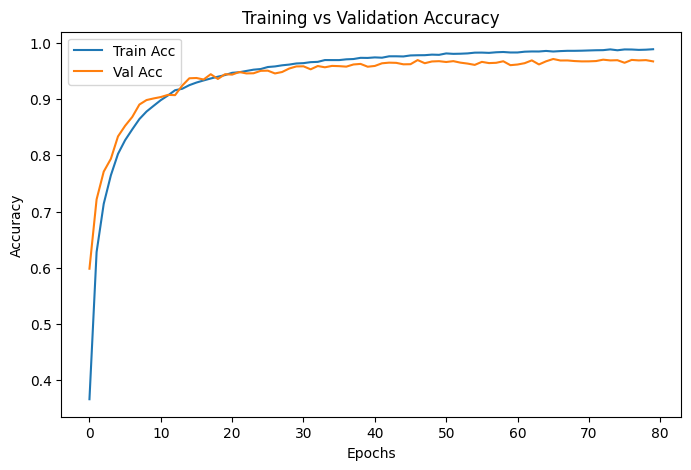

In [14]:
plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"], label="Train Acc")
plt.plot(history.history["val_accuracy"], label="Val Acc")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


In [15]:
# Check if GPU is available
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        # Set TensorFlow to only use the first GPU
        tf.config.experimental.set_visible_devices(gpus[0], 'GPU')
        # Enable memory growth to prevent the GPU from allocating all memory at once
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        logical_gpus = tf.config.experimental.list_logical_devices('GPU')
        print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
    except RuntimeError as e:
        print(e)
else:
    print("No GPU devices found.")

Physical devices cannot be modified after being initialized


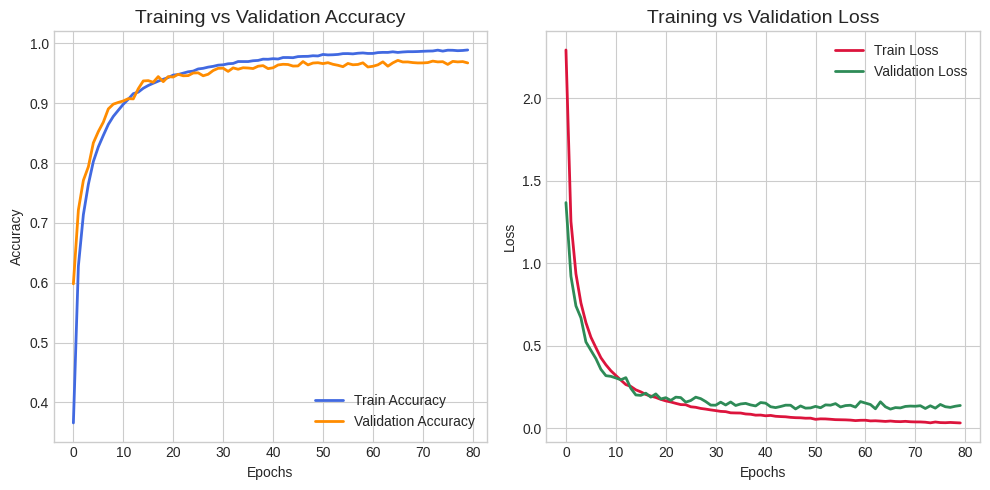

In [16]:
plt.style.use("seaborn-v0_8-whitegrid")
plt.figure(figsize=(10,5))

# Accuracy Plot
plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Train Accuracy", color="royalblue", linewidth=2)
plt.plot(history.history["val_accuracy"], label="Validation Accuracy", color="darkorange", linewidth=2)
plt.title("Training vs Validation Accuracy", fontsize=14)
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# Loss Plot
plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Train Loss", color="crimson", linewidth=2)
plt.plot(history.history["val_loss"], label="Validation Loss", color="seagreen", linewidth=2)
plt.title("Training vs Validation Loss", fontsize=14)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


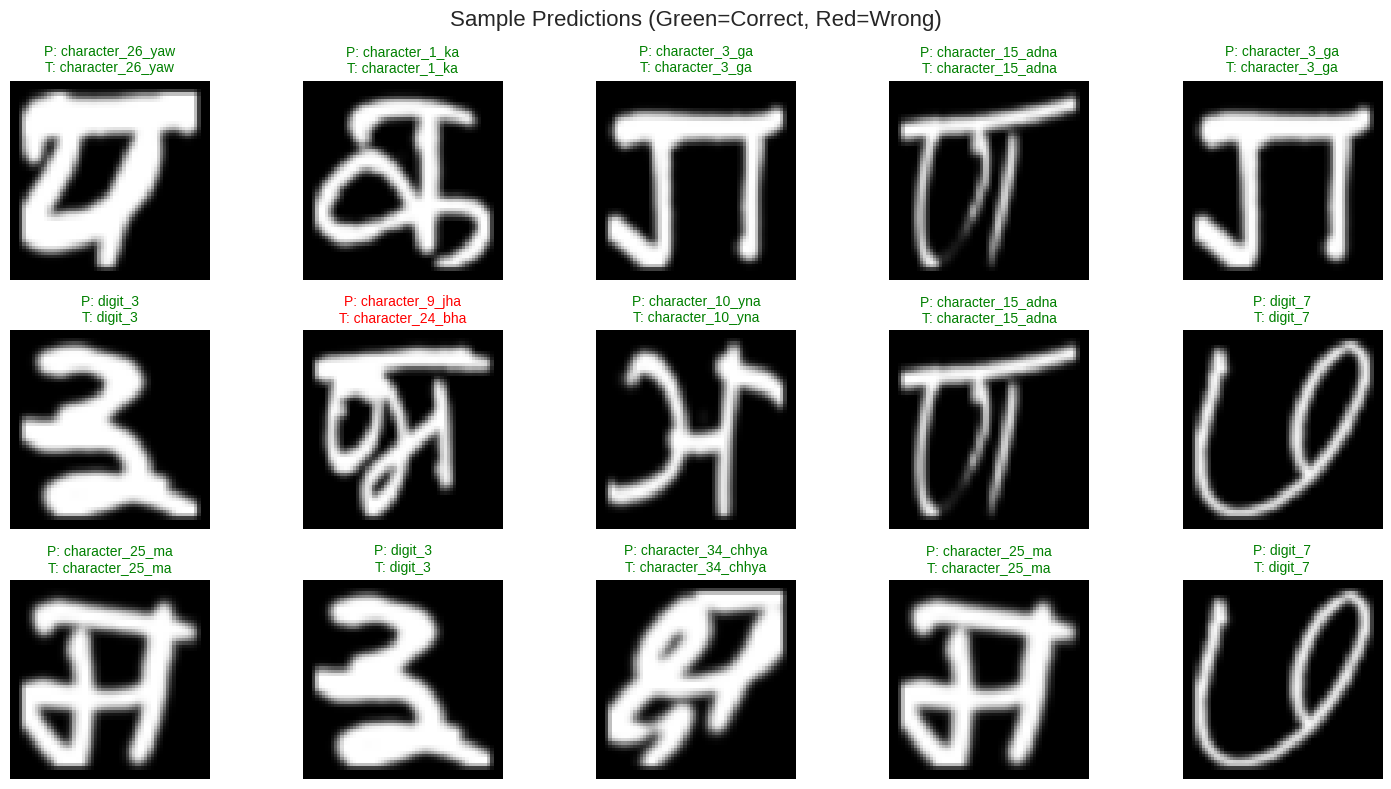

In [17]:
import random

# Take a batch from test dataset
for images, labels in test_ds.take(1):
    preds = vit_model.predict(images)
    pred_labels = np.argmax(preds, axis=1)

    plt.figure(figsize=(15, 8))
    for i in range(15):
        idx = random.randint(0, len(images)-1)
        ax = plt.subplot(3, 5, i+1)
        plt.imshow(images[idx])
        color = "green" if pred_labels[idx] == labels[idx] else "red"
        plt.title(f"P: {class_names[pred_labels[idx]]}\nT: {class_names[labels[idx]]}", color=color, fontsize=10)
        plt.axis("off")
    plt.suptitle("Sample Predictions (Green=Correct, Red=Wrong)", fontsize=16)
    plt.tight_layout()
    plt.show()

In [18]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

y_true, y_pred = [], []
for images, labels in test_ds:
    preds = vit_model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(y_true, y_pred, target_names=class_names))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━

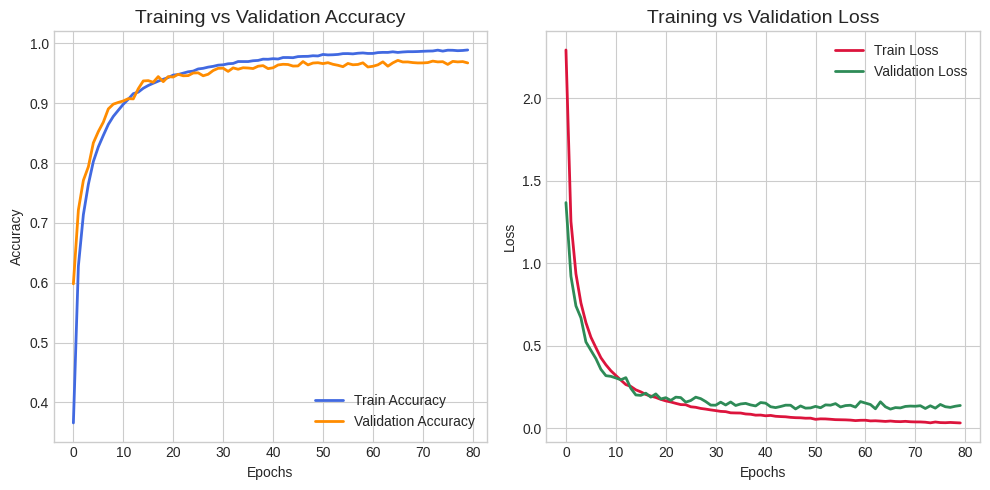

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")
plt.figure(figsize=(10,5))

# Accuracy Plot
plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Train Accuracy", color="royalblue", linewidth=2)
plt.plot(history.history["val_accuracy"], label="Validation Accuracy", color="darkorange", linewidth=2)
plt.title("Training vs Validation Accuracy", fontsize=14)
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# Loss Plot
plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Train Loss", color="crimson", linewidth=2)
plt.plot(history.history["val_loss"], label="Validation Loss", color="seagreen", linewidth=2)
plt.title("Training vs Validation Loss", fontsize=14)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


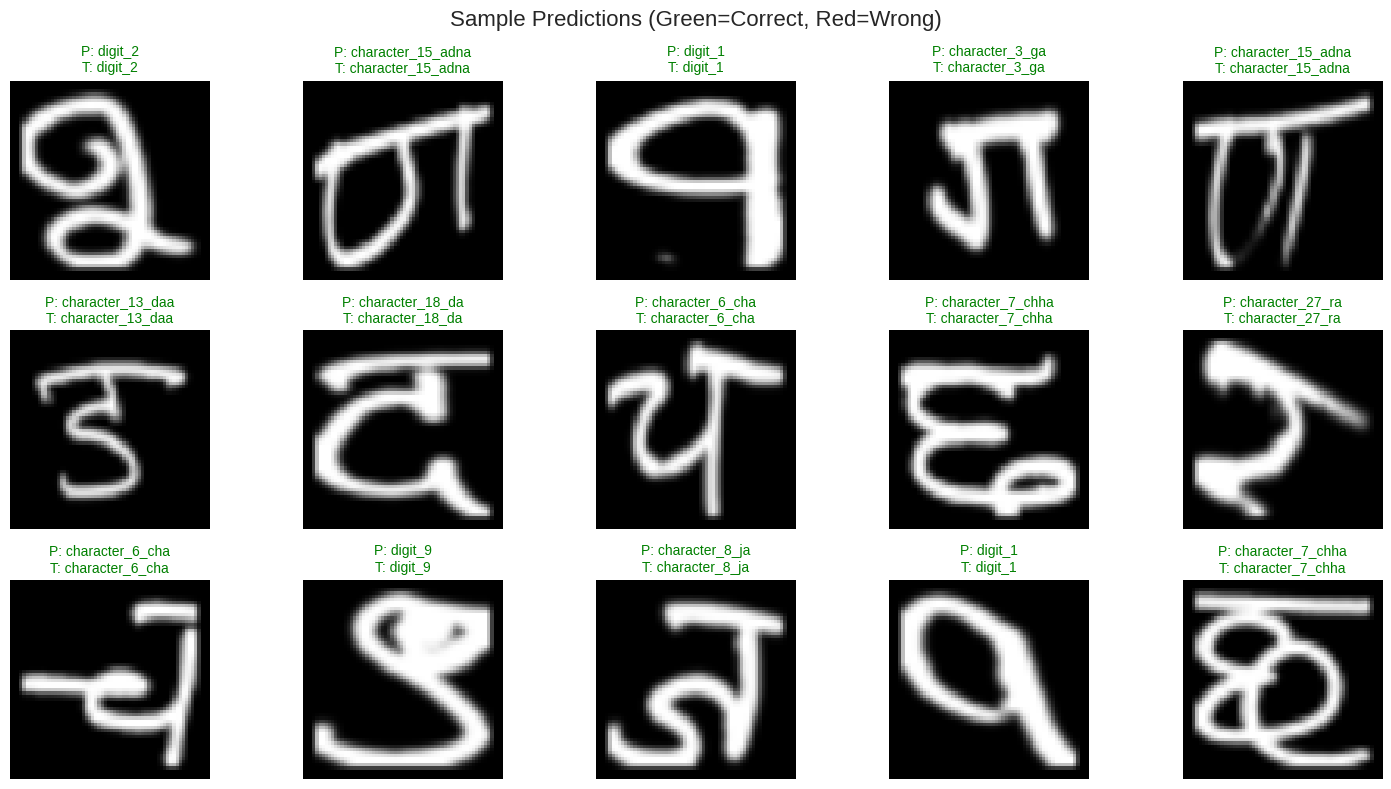

In [20]:
import random

# Take a batch from test dataset
for images, labels in test_ds.take(1):
    preds = vit_model.predict(images)
    pred_labels = np.argmax(preds, axis=1)

    plt.figure(figsize=(15, 8))
    for i in range(15):
        idx = random.randint(0, len(images)-1)
        ax = plt.subplot(3, 5, i+1)
        plt.imshow(images[idx])
        color = "green" if pred_labels[idx] == labels[idx] else "red"
        plt.title(f"P: {class_names[pred_labels[idx]]}\nT: {class_names[labels[idx]]}", color=color, fontsize=10)
        plt.axis("off")
    plt.suptitle("Sample Predictions (Green=Correct, Red=Wrong)", fontsize=16)
    plt.tight_layout()
    plt.show()


In [21]:
vit_model.save("/content/drive/MyDrive/vit_devanagari_final.h5")
print("✅ Model saved successfully!")

# Optionally export plots as PNG for paper
plt.savefig("/content/drive/MyDrive/accuracy_loss_curves.png", dpi=300, bbox_inches='tight')


✅ Model saved successfully!


<Figure size 640x480 with 0 Axes>

In [22]:
from google.colab import files

# Save model temporarily in Colab
vit_model.save("vit_devanagari_final.h5")

# Download to your PC
files.download("vit_devanagari_final.h5")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [23]:
import numpy as np
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Collect true & predicted labels
y_true, y_pred = [], []
for images, labels in test_ds:
    preds = vit_model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Compute per-class accuracy
class_acc = []
for i, class_name in enumerate(class_names):
    idx = np.where(y_true == i)[0]
    acc = accuracy_score(y_true[idx], y_pred[idx])
    class_acc.append(acc)

# Sort by accuracy for better visualization
sorted_idx = np.argsort(class_acc)
sorted_class_names = [class_names[i] for i in sorted_idx]
sorted_acc = [class_acc[i] for i in sorted_idx]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━

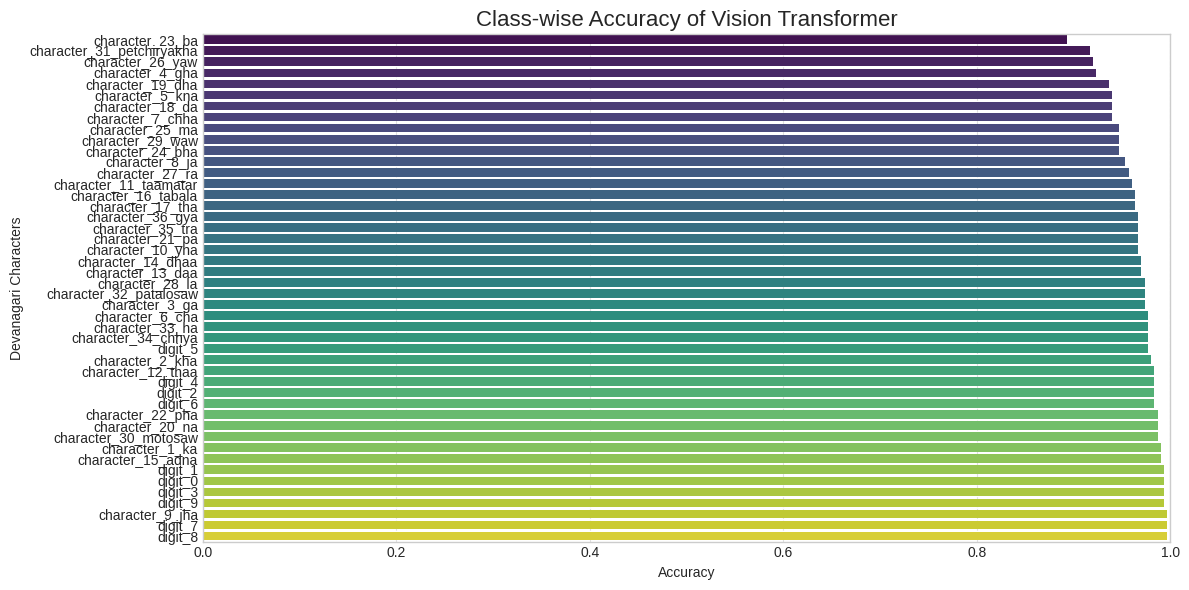

In [24]:
plt.figure(figsize=(12, 6))

# Convert data into a dataframe (better for Seaborn)
import pandas as pd
df = pd.DataFrame({
    "Class": sorted_class_names,
    "Accuracy": sorted_acc
})

# Create the barplot
sns.barplot(
    data=df,
    x="Accuracy",
    y="Class",
    hue="Class",              # assign hue to avoid warning
    palette="viridis",
    dodge=False,
    legend=False              # remove redundant legend
)

plt.title("Class-wise Accuracy of Vision Transformer", fontsize=16)
plt.xlabel("Accuracy")
plt.ylabel("Devanagari Characters")
plt.xlim(0, 1)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


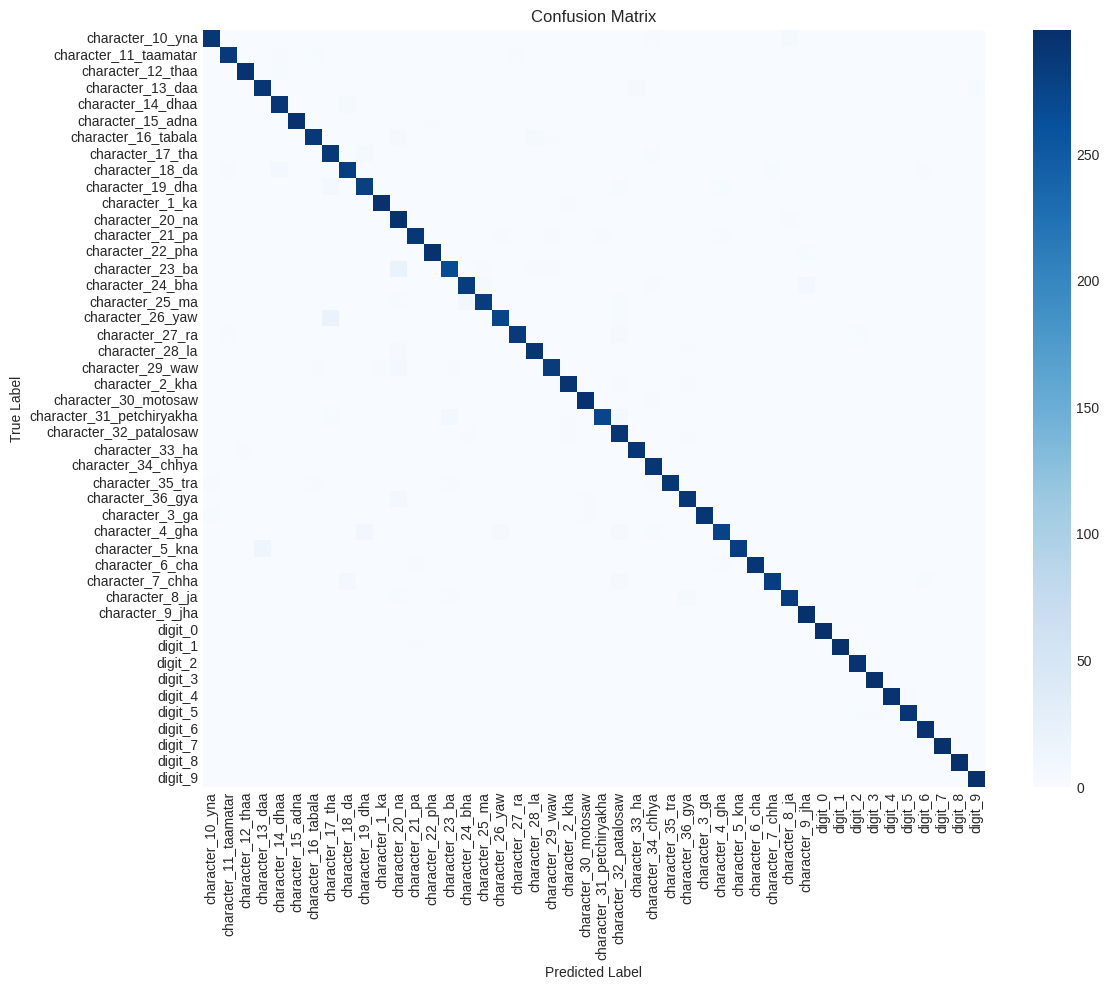

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=False, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

In [26]:
from sklearn.metrics import accuracy_score, precision_score, f1_score, roc_auc_score, roc_curve
import numpy as np

# Calculate accuracy, precision, and f1-score
accuracy = accuracy_score(y_true, y_pred)
# For multiclass classification, precision and f1-score need averaging
precision = precision_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision (weighted): {precision:.4f}")
print(f"F1-score (weighted): {f1:.4f}")

# ROC AUC Score (requires probability estimates and is for binary or multilabel)
# For multiclass, you'd typically need to calculate AUC for each class against the rest (OvR)
# This example calculates AUC for each class and then averages (macro)
# Note: This requires probability predictions, not just predicted classes
# You'll need to get the raw model predictions (probabilities) if you haven't already
# If preds contains probabilities:
# try:
#     roc_auc_ovr = roc_auc_score(y_true, preds, multi_class='ovr', average='macro')
#     print(f"ROC AUC (OvR, macro avg): {roc_auc_ovr:.4f}")
# except ValueError:
#      print("ROC AUC calculation requires probability predictions.")

# If you only have hard predictions (y_pred), ROC AUC is not directly applicable without converting to one-hot and getting probabilities
# For simplicity, we will not calculate ROC AUC here unless probability predictions are available.
print("\nNote: ROC AUC calculation requires probability predictions for multiclass problems.")

Accuracy: 0.9673
Precision (weighted): 0.9682
F1-score (weighted): 0.9674

Note: ROC AUC calculation requires probability predictions for multiclass problems.
